In [ ]:
import pandas as pd
import xgboost
import joblib
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostClassifier
from sklearn.metrics import (accuracy_score, precision_score,recall_score, f1_score, roc_auc_score, confusion_matrix, precision_recall_curve, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns

  Using cached mlflow-3.14.0-py3-none-any.whl.metadata (49 kB)
  Using cached mlflow_skinny-3.14.0-py3-none-any.whl.metadata (50 kB)
  Using cached mlflow_tracing-3.14.0-py3-none-any.whl.metadata (19 kB)
  Using cached flask_cors-6.0.5-py3-none-any.whl.metadata (5.4 kB)
  Using cached flask-3.1.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached cryptography-48.0.1-cp311-abi3-manylinux_2_34_x86_64.whl.metadata (4.3 kB)
  Using cached docker-7.1.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached graphene-3.4.3-py2.py3-none-any.whl.metadata (6.9 kB)
  Using cached skops-0.14.0-py3-none-any.whl.metadata (4.4 kB)
  Using cached databricks_sdk-0.118.0-py3-none-any.whl.metadata (43 kB)
  Using cached fastapi-0.137.2-py3-none-any.whl.metadata (27 kB)
  Using cached gitpython-3.1.50-py3-none-any.whl.metadata (14 kB)
  Using cached opentelemetry_sdk-1.42.1-py3-none-any.whl.metadata (1.7 kB)
  Using cached blinker-1.9.0-py3-none-a

# Loading Provided RFM Modeling Snapshot

In [ ]:
rfm_df = pd.read_csv('https://raw.githubusercontent.com/0-Deepak/customer-churn-eda-and-data-audit/refs/heads/main/data/raw/rfm_modeling_snapshot.csv')
rfm_df.head()

,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,...,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,...,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,...,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,...,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,...,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,...,18,95,4,1,1,3,1,9,0,train


In [3]:
# imputing Loyalty Tier value
rfm_df['loyalty_tier'] = rfm_df['loyalty_tier'].fillna('Not Enrolled')

In [4]:
validation_set = rfm_df[rfm_df['split'] == 'validation']
train_set = rfm_df[rfm_df['split'] == 'train']
test_set = rfm_df[rfm_df['split'] == 'test']

In [5]:
print(len(train_set[train_set['churn_next_60d'] == 1]))
print(len(train_set[train_set['churn_next_60d'] == 0]))

812
916


In [6]:
X_train, y_train = train_set.drop(columns=['customer_id','churn_next_60d','snapshot_date', 'split']), train_set['churn_next_60d']
X_test, y_test = test_set.drop(columns=['churn_next_60d','snapshot_date', 'split']), test_set['churn_next_60d']
X_val, y_val = validation_set.drop(columns=['churn_next_60d','snapshot_date', 'split']), train_set['churn_next_60d']

In [7]:
def get_classification_metrics(y_pred, model_name=None):
  y_true = y_test
  metrics =[
    ['accuracy',  accuracy_score(y_true, y_pred)],
    ['precision', precision_score(y_true, y_pred)],
    ['recall',    recall_score(y_true, y_pred, pos_label=1)],
    ['f1-Score',  f1_score(y_true, y_pred)]
  ]
  metrics_df = pd.DataFrame(columns=['metrics','value'],data=metrics)
  return metrics_df


In [9]:
categorical_cols = X_train.select_dtypes(include=['object']).columns
numerical_cols = X_train.select_dtypes(exclude='object').columns

preprocessor = ColumnTransformer([
    ('scaler', StandardScaler(), numerical_cols),
    ('encoder', OneHotEncoder(), categorical_cols)
])

In [10]:
# training baseline model

In [11]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=42))
])

lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](25,)","['city_tier','age_group','acquisition_channel',...,'email_opens_30d', 'campaign_clicks_30d','last_visit_days_ago']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...), ('encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'`

In [12]:
y_pred = lr_pipeline.predict(X_test)
get_classification_metrics(y_pred, 'lr_pipeline')

,metrics,value
0,accuracy,0.791667
1,precision,0.798780
2,recall,0.779762
3,f1-Score,0.789157


logistic regression model achieved recall of 0.77 and precision of 0.79, we will use this as a baseline for model training

In [13]:
# training Random forest model

In [14]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train)
y_pred = rf_pipeline.predict(X_test)
get_classification_metrics(y_pred)

,metrics,value
0,accuracy,0.803571
1,precision,0.822785
2,recall,0.773810
3,f1-Score,0.797546


In [15]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgboost.XGBClassifier(random_state=42, eval_set=[(X_val, y_val)]))
])

xgb_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:48:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "eval_set" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](25,)","['city_tier','age_group','acquisition_channel',...,'email_opens_30d', 'campaign_clicks_30d','last_visit_days_ago']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...), ('encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'`

In [16]:
y_pred = xgb_pipeline.predict(X_test)
get_classification_metrics(y_pred)

,metrics,value
0,accuracy,0.803571
1,precision,0.786517
2,recall,0.833333
3,f1-Score,0.809249


In [17]:

cb_classifier_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model', CatBoostClassifier(iterations=1000, learning_rate=0.05, depth=6, loss_function='Logloss', eval_metric='F1', random_seed=42 ))])

cb_classifier_pipeline.fit(X_train, y_train)

0:	learn: 0.7551155	total: 47ms	remaining: 47s
1:	learn: 0.7525424	total: 48.1ms	remaining: 24s
2:	learn: 0.7686170	total: 49.1ms	remaining: 16.3s
3:	learn: 0.7649402	total: 50.1ms	remaining: 12.5s
4:	learn: 0.7769029	total: 51.1ms	remaining: 10.2s
5:	learn: 0.7761780	total: 52.1ms	remaining: 8.63s
6:	learn: 0.7827789	total: 53.1ms	remaining: 7.53s
7:	learn: 0.7862248	total: 54.1ms	remaining: 6.7s
8:	learn: 0.7851562	total: 55ms	remaining: 6.06s
9:	learn: 0.7861799	total: 56ms	remaining: 5.54s
10:	learn: 0.7842623	total: 57ms	remaining: 5.12s
11:	learn: 0.7848267	total: 58ms	remaining: 4.77s
12:	learn: 0.7866492	total: 59ms	remaining: 4.48s
13:	learn: 0.7866492	total: 60ms	remaining: 4.22s
14:	learn: 0.7868852	total: 61ms	remaining: 4s
15:	learn: 0.7889908	total: 62ms	remaining: 3.81s
16:	learn: 0.7874016	total: 63ms	remaining: 3.64s
17:	learn: 0.7881967	total: 64ms	remaining: 3.49s
18:	learn: 0.7905759	total: 65ms	remaining: 3.36s
19:	learn: 0.7929458	total: 66ms	remaining: 3.23s
20:	

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](25,)","['city_tier','age_group','acquisition_channel',...,'email_opens_30d', 'campaign_clicks_30d','last_visit_days_ago']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...), ('encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'`

In [18]:
y_pred = cb_classifier_pipeline.predict(X_test)
get_classification_metrics(y_pred)

,metrics,value
0,accuracy,0.791667
1,precision,0.778409
2,recall,0.815476
3,f1-Score,0.796512


In [19]:
# Tuning Models

In [20]:
rf_param_grid = {
      'model__n_estimators': [50, 100, 200],
      'model__max_depth':[10, 20, 30, None],
      'model__min_samples_leaf':[1, 2, 4],
      'model__min_samples_split':[2, 5, 10]
}

tuned_rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(class_weight='balanced',random_state=42))
])

rf_grid = GridSearchCV(
    estimator=tuned_rf_pipeline,
    param_grid=rf_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [10, 20, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluatio

In [21]:
y_pred = rf_grid.predict(X_test)
get_classification_metrics(y_pred)

,metrics,value
0,accuracy,0.806548
1,precision,0.823899
2,recall,0.779762
3,f1-Score,0.801223


In [22]:
xgb_param_grid = {
      'model__n_estimators': [200, 400, 600],
      'model__max_depth':[3, 5, 7, None],
      'model__min_child_weight':[1,3,5],
      'model__learning_rate':[0.001, 0.01, 0.1, 1],
      'model__subsamples':[0.4, 0.6, 0.8, 1.0]
}

tuned_xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgboost.XGBClassifier(objective='binary:logistic', random_state=42))
])


xgb_grid = GridSearchCV(
    estimator=tuned_xgb_pipeline,
    param_grid=xgb_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 576 candidates, totalling 2880 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:52:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "subsamples" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.001, 0.01, ...], 'model__max_depth': [3, 5, ...], 'model__min_child_weight': [1, 3, ...], 'model__n_estimators': [200, 400, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metric

In [23]:
y_pred = xgb_grid.predict(X_test)
get_classification_metrics(y_pred)

,metrics,value
0,accuracy,0.797619
1,precision,0.787356
2,recall,0.815476
3,f1-Score,0.801170


In [26]:
# Evaluation
def get_extended_classfication_metrics(model_name, y_pred, y_pred_proba):
  metrics = {
    'Model': model_name,
    'Accuracy':  accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall':    recall_score(y_test, y_pred),
    'F1-Score':  f1_score(y_test, y_pred),
    'AUC-ROC':   roc_auc_score(y_test, y_pred_proba)
  }
  return metrics

def get_curve_metrics(model, curve_type='roc', prob_class=1):
  y_pred_proba = model.predict_proba(X_test)
  if curve_type == 'pr':
    return precision_recall_curve(y_test, y_pred_proba[:,prob_class])
  return roc_curve(y_test, y_pred_proba[:,prob_class])

def get_model_from_pipeline(pipeline, tuned=False):
  if tuned:
    pipeline = pipeline.best_estimator_
  preprocessor = pipeline.named_steps['preprocessor']
  model = pipeline.named_steps['model']
  return model, preprocessor

def get_features_importance(model, preprocessor):
  importance = pd.DataFrame({
      'importance':model.feature_importances_,
      'features':preprocessor.get_feature_names_out()
  }).sort_values(by='importance', ascending=False)

  importance['original_features'] = importance['features'].str.split('__').str[1].str.split('_').str[0]
  agg_feat_imp = importance[['importance','original_features']].groupby('original_features').sum().sort_values(by='importance',ascending=True)
  return agg_feat_imp.index, agg_feat_imp['importance'].values


Comparision Table of Metrics among Models

In [29]:
metrics_df = pd.DataFrame([
  get_extended_classfication_metrics('Logistic Reg (Baseline)',lr_pipeline.predict(X_test), lr_pipeline.predict_proba(X_test)[:,1]),
  get_extended_classfication_metrics('Random Forest',rf_grid.predict(X_test), rf_grid.predict_proba(X_test)[:,1]),
  get_extended_classfication_metrics('XGBoost',xgb_grid.predict(X_test), xgb_grid.predict_proba(X_test)[:,1]),
  get_extended_classfication_metrics('CatBoost',cb_classifier_pipeline.predict(X_test), cb_classifier_pipeline.predict_proba(X_test)[:,1])
])
metrics_df.set_index('Model')

,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Model,,,,,
Logistic Reg (Baseline),0.791667,0.798780,0.779762,0.789157,0.884779
Random Forest,0.806548,0.823899,0.779762,0.801223,0.881165
XGBoost,0.797619,0.787356,0.815476,0.801170,0.864229
CatBoost,0.791667,0.778409,0.815476,0.796512,0.871953


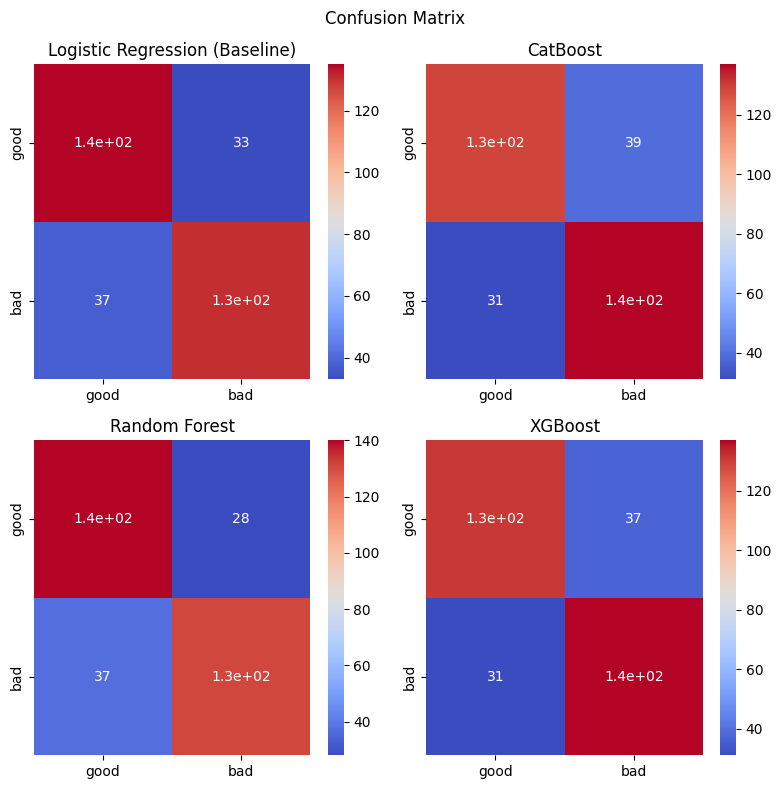

In [30]:
# Box plots of feature distributions by risk category
rf_confusion_mat = confusion_matrix(y_test, rf_grid.predict(X_test))
xgb_confusion_mat = confusion_matrix(y_test, xgb_grid.predict(X_test))
cb_confusion_mat = confusion_matrix(y_test, cb_classifier_pipeline.predict(X_test))
lr_confusion_mat = confusion_matrix(y_test, lr_pipeline.predict(X_test))

fig, axes = plt.subplots(2,2, figsize=(8, 8))
sns.heatmap(lr_confusion_mat, annot=True, cmap='coolwarm', ax=axes[0,0], xticklabels=['good', 'bad'], yticklabels=['good','bad'])
sns.heatmap(cb_confusion_mat, annot=True, cmap='coolwarm', ax=axes[0,1], xticklabels=['good', 'bad'], yticklabels=['good','bad'])
sns.heatmap(rf_confusion_mat, annot=True, cmap='coolwarm', ax=axes[1,0], xticklabels=['good', 'bad'], yticklabels=['good','bad'])
sns.heatmap(xgb_confusion_mat, annot=True, cmap='coolwarm', ax=axes[1,1], xticklabels=['good', 'bad'], yticklabels=['good','bad'])
fig.suptitle('Confusion Matrix')

axes[0,0].set_title('Logistic Regression (Baseline)')
axes[0,1].set_title('CatBoost')
axes[1,0].set_title('Random Forest')
axes[1,1].set_title('XGBoost')

plt.tight_layout()
plt.show()

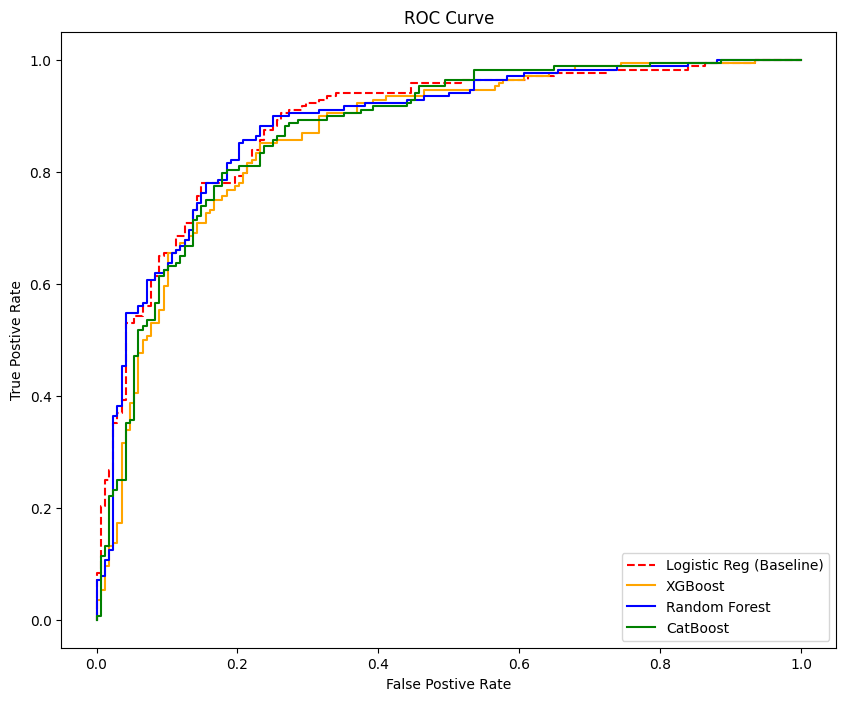

In [31]:
xgb_fpr, xgb_tpr, _ = get_curve_metrics(xgb_grid)
lr_fpr, lr_tpr, _ = get_curve_metrics(lr_pipeline)
rf_fpr, rf_tpr, _ = get_curve_metrics(rf_grid)
cb_fpr, cb_tpr, _ = get_curve_metrics(cb_classifier_pipeline)

plt.figure(figsize=(10,8))
plt.title('ROC Curve')
plt.plot(lr_fpr, lr_tpr, color='red', linestyle='--', label='Logistic Reg (Baseline)')
plt.plot(xgb_fpr, xgb_tpr, color='orange', label='XGBoost')
plt.plot(rf_fpr, rf_tpr, color='blue', label='Random Forest')
plt.plot(cb_fpr, cb_tpr, color='green', label='CatBoost')
plt.xlabel('False Postive Rate')
plt.ylabel('True Postive Rate')
plt.legend()
plt.plot()
plt.show()

Feature Importance for Tree Model

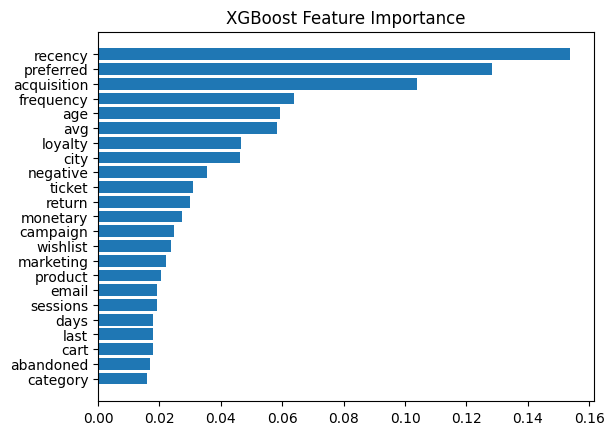

In [32]:
xgb_model, xgb_preprocessor = get_model_from_pipeline(xgb_grid,True)
xgb_feat_names, xgb_feat_imp = get_features_importance(xgb_model, xgb_preprocessor)
plt.title('XGBoost Feature Importance')
plt.barh(xgb_feat_names, xgb_feat_imp)
plt.show()

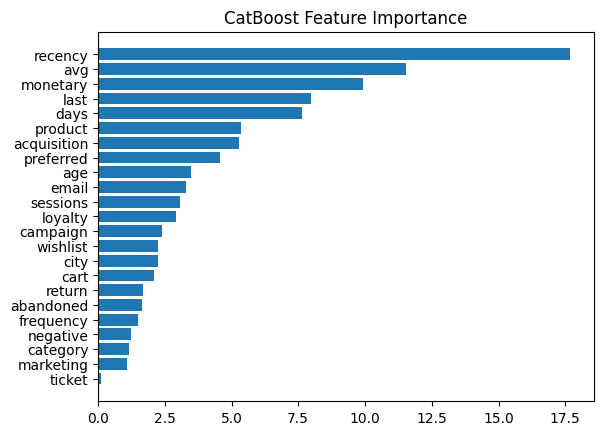

In [33]:
cb_model, cb_preprocessor = get_model_from_pipeline(cb_classifier_pipeline)
cb_feat_names, cb_feat_imp = get_features_importance(cb_model, cb_preprocessor)
plt.title('CatBoost Feature Importance')
plt.barh(cb_feat_names, cb_feat_imp)
plt.show()

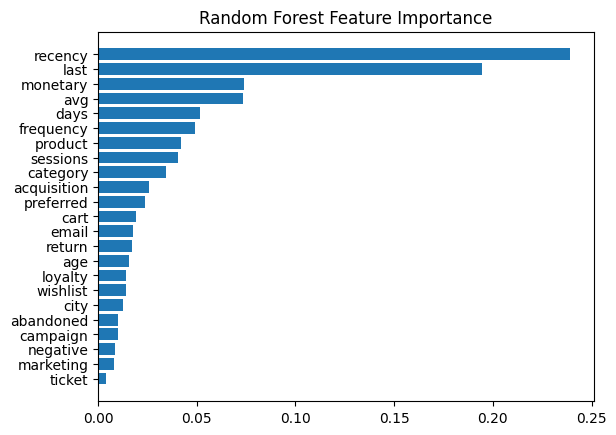

In [34]:
rf_model, rf_preprocessor = get_model_from_pipeline(rf_grid,True)
rf_feat_names, rf_feat_imp = get_features_importance(rf_model, rf_preprocessor)
plt.title('Random Forest Feature Importance')
plt.barh(rf_feat_names, rf_feat_imp)
plt.show()

Best Performing Model is CatBoost, Below is the Performance recall curve for it

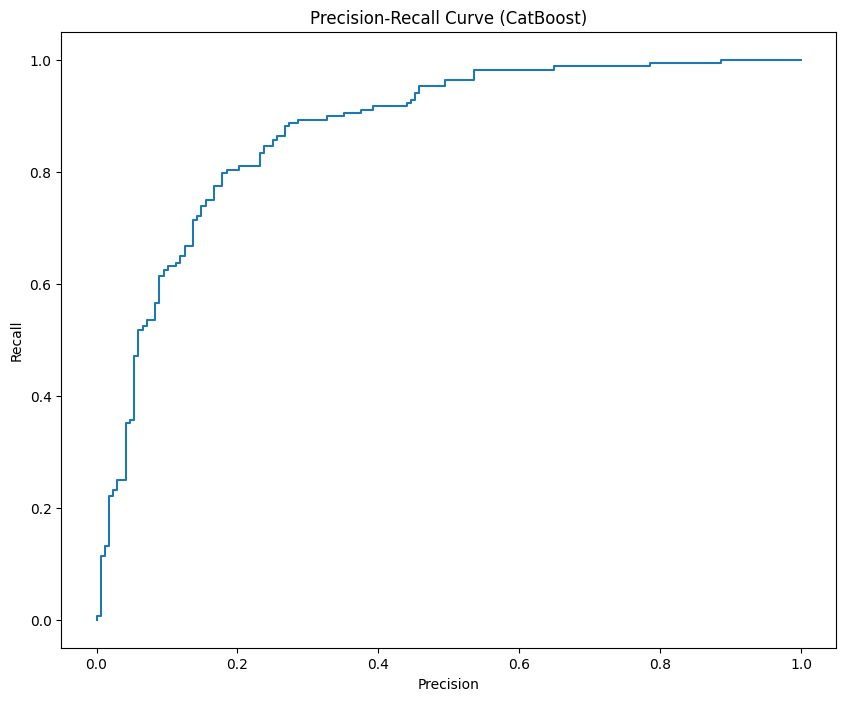

In [36]:
cb_precision, cb_recall, _ = get_curve_metrics(cb_classifier_pipeline)

plt.figure(figsize=(10,8))
plt.plot(cb_precision, cb_recall)
plt.title('Precision-Recall Curve (CatBoost)')
plt.xlabel('Precision')
plt.ylabel('Recall')
plt.plot()
plt.show()